Day 17
Block 1 of hour 1

Why do we need this MSE,MAE,RMSE
After training a model we need to ask that how good my model is
So we need these evaluation metrics

MAE
 = (1/n)* sum (|y-y^|)
Average of absolute error
 Insight -treat all error equally

 MSE - we know it earlier

 RMSE- square root of MSE
Why RMSE?
Brings error back to original unit


Comparison

Metric	                                  Behavior

MAE	                                    Linear penalty

MSE	                                     Squared penalty

RMSE	                                     Scaled MSE

When to Use What

👉 Use MAE when:

All errors matter equally , most robust to outliers

👉 Use MSE when:

Large errors are dangerous

👉 Use RMSE when:

You want error in original unit, same unit as target

MAE and RMSE both are interpretable  

RMSE is just MSE converted back to original unit

R2 score - coefficient of Determination
How well your model explains the variation in data

 = 1 - (SS_resi)/SS_Tot

SS_resi = sum(y-y^)**2
SS_tot = sum(y-mean(y))**2

here we compare the model to baseline
if R = 1 --- model is perfect - it means predictions 
are same as original data so SS_resi = 0
if R = 0 ---- model is same as baseline (mean)
<0 - model is worse than baseline

gives relative performance - help compare model easily

R² = 0 → model equals baseline (mean prediction)

R² < 0 → model worse than baseline (error > total variation)

Higher R² is not always better due to risk of overfitting


Residual Plot

Predicted values (x-axis) vs Residuals (y-axis)
Is the model capturing patterns correctly?

Characteristics
• Random scatter  
• Around zero line  
• No pattern
------------good model

Characteristics
• Curve pattern  
• Funnel shape  
• Structured pattern
------------- bad model

import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Block 4
overfitting

Metric	                          Value

Train error	                      Low ✔

Test error	                       High ❌

Why
• Too many features  
• Too complex model  
• Too little data  
• Noise in data

low bias and high variance - overfitting

Real meaning
model learns signal and noise  instead of only signal

How to Fix Overfitting
✅ 1. More Data
Gives better generalization
✅ 2. Reduce Complexity
Simpler model
Lower polynomial degree
✅ 3. Regularization (L1/L2)
👉 Penalizes large weights
✅ 4. Feature Selection

Residual plot connection

may look random on train but bad on test

In [2]:
import pandas as pd
df = pd.read_csv("house_price_v6_final.csv")
df.head()

,quality_area,garagecars,area_per_room,renovation_age,house_age,target
0,11970,2,190.000000,5,5,12.247699
1,7572,2,180.285714,31,31,12.109016
2,12502,2,255.142857,6,7,12.317171
3,12019,3,214.625000,36,91,11.849405
4,17584,3,219.800000,8,8,12.429220


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df.drop('target',axis=1)
y = df['target']
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size =0.2,random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Test
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("Train:", mae_train, mse_train, rmse_train, r2_train)
print("Test :", mae_test, mse_test, rmse_test, r2_test)

Train: 0.12471953076013637 0.027625524541072862 0.16620927934707155 0.8232162381716158
Test : 0.13223085414696817 0.03232284098724896 0.17978554165240584 0.7953453626652762


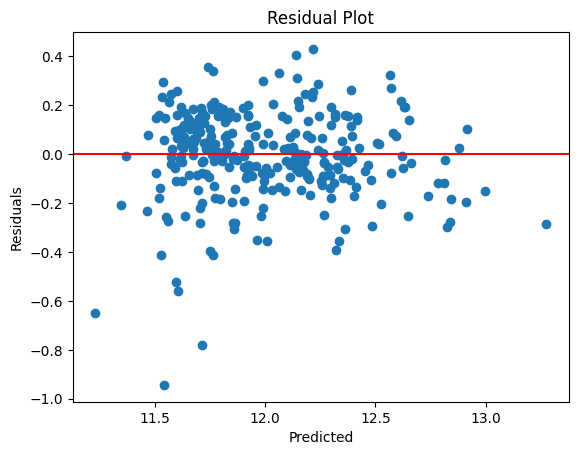

In [8]:
## Residual Plot
import matplotlib.pyplot as plt

residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
# Hour 6
## Compare Models
## Linear v/s Polynomial Regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear": LinearRegression(),
    "Poly_2": Pipeline([
        ("poly",PolynomialFeatures(degree=2)),
        ("linreg", LinearRegression())
    ]),
    "Poly_5": Pipeline([
        ("poly", PolynomialFeatures(degree=5)),
        ("linreg", LinearRegression())
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name} → MSE: {mse:.4f}, R²: {r2:.4f}")

Linear → MSE: 0.0323, R²: 0.7953
Poly_2 → MSE: 0.0309, R²: 0.8043
Poly_5 → MSE: 0.0752, R²: 0.5236


## Hour 8
What is Project Tuning?

👉 Improving model performance using:

features + parameters + model choice

1. Feature ENgineering
- create new feature
- remove unwanted features
- try polynomial feature

2. Try different models

Linear Regression
Polynomial
Decision Tree
Random Forest

3. Hyperparameter Tuning (Core Idea)
👉 Hyperparameters =
Settings you choose BEFORE training the model
like tree depth, degree in Decision Tree model

4. Cross Validation (IMPORTANT)
trainig data is divided into k fold and then we perform validation
suppose k = 5
5 scores → take average

5. Why It’s Better
👉 Cross-validation:
Uses entire data efficiently ✔
👉 Reduces:
Bias due to random split ✔
Test data is NOT used in cross-validation ❌
Cross-validation = simulate multiple train-test splits on training data
We divide training data into K parts, train K times, and average performance

5. Scaling

👉 Especially for:

Linear models
Polynomial features

When to Stop? :-
👉 When:
Improvement becomes very small
👉 Or:
Model becomes too complex


In [21]:
# Try 2 things:
# Polynomial degree 2
# Remove one feature
# 👉 Compare:
# MSE
# R²

df.head()

## Dropping one feature
df1 = df.drop('garagecars',axis = 1)
df1.head()
X_df1 = df1.drop('target',axis=1)
y_df1 = df1['target']

X_df1_train,X_df1_test,y_df1_train,y_df1_test = train_test_split(X_df1,y_df1,
                                                test_size=0.2,random_state=42)
model_df1 = LinearRegression()
model_df1.fit(X_df1_train,y_df1_train)
y_df1_pred = model_df1.predict(X_df1_test)
mse = mean_squared_error(y_df1_test, y_df1_pred)
r2 = r2_score(y_df1_test, y_df1_pred)

print(f"mse_drop:",{mse},"r2_drop:",{r2})
## Polynomial Feature
model = Pipeline([("poly",PolynomialFeatures(degree=2)),("linreg",LinearRegression())])
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mse_pol_2:",{mse},"r2_pol_2:",{r2})

## Polynomial Feature
model_deg_4 = Pipeline([("poly",PolynomialFeatures(degree=4)),("linreg",LinearRegression())])
model_deg_4.fit(X_train,y_train)
y_pred = model_deg_4.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mse_pol_4:",{mse},"r2_pol_4:",{r2})


## USe cross validation for drop one feature
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
scores_df1 = cross_val_score(model_df1, X_df1, y_df1, cv=5, scoring='r2')
print(scores_df1)
print("Average R2_drop_one_feature:", scores_df1.mean())

## USe cross validation for deg -2 polynomial
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
scores_dg_2 = cross_val_score(model, X, y, cv=5, scoring='r2')
print(scores_dg_2)
print("Average R2_deg_2:", scores_dg_2.mean())

## USe cross validation for deg -4 polynomial
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
scores_dg_4 = cross_val_score(model_deg_4, X, y, cv=5, scoring='r2')
print(scores_dg_4)
print("Average R2_deg_4:", scores_dg_4.mean())

mse_drop: {0.03530197566299544} r2_drop: {0.7764827346284426}
mse_pol_2: {0.030906939903123418} r2_pol_2: {0.8043102529417179}
mse_pol_4: {0.03126409116004548} r2_pol_4: {0.8020489213654538}
[0.80163835 0.81551498 0.80991171 0.80284572 0.76966092]
Average R2_drop_one_feature: 0.7999143372089682
[0.82820168 0.83784803 0.81728756 0.81770603 0.81108013]
Average R2_deg_2: 0.8224246866787286
[0.74473182 0.83177765 0.80190209 0.82909116 0.80667318]
Average R2_deg_4: 0.802835179422852


In [ ]:
## Hour 7
## Problem 1
## How many subarays have sum k
nums = [ 1,1,1,1]
k = 2

def subarr_sum_k(nums,k):
    prefix_sum =0
    hashmap = {0:1}
    count = 0
    for num in nums:
        prefix_sum+=num
        if prefix_sum -k in hashmap:
            count+=hashmap[prefix_sum-k]
        hashmap[prefix_sum] = hashmap.get(prefix_sum,0)+1
    return count
print(subarr_sum_k(nums,k))

prefix_sum: 1
hasmap {0: 1, 1: 1}
prefix_sum: 2
prefix_sum-k: 0
count 1
hasmap {0: 1, 1: 1}
hasmap {0: 1, 1: 1, 2: 1}
prefix_sum: 3
prefix_sum-k: 1
count 2
hasmap {0: 1, 1: 1, 2: 1}
hasmap {0: 1, 1: 1, 2: 1, 3: 1}
prefix_sum: 4
prefix_sum-k: 2
count 3
hasmap {0: 1, 1: 1, 2: 1, 3: 1}
hasmap {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}
3
